<a href="https://colab.research.google.com/github/Laahir/MAT-422/blob/main/MAT422_HW3_Section_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laahir/MAT-422/blob/main/MAT422_HW3_Section_3_2.ipynb)

# MAT 422 - Homework 3 - Section 3.2: Limits, Derivatives, and Taylor's Theorem

**Name:** Laahir
**Course:** MAT 422
**Topics covered:** limits and continuity, derivatives, Taylor's theorem

This one is right in my wheelhouse since I help students with Precalc and Calc I every week. Limits and derivatives are exactly where a lot of them get stuck, so I tried to explain things the way I would at the tutoring desk, and I used a learning curve (score vs hours studied) as the main example for derivatives.

In [11]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

## 3.2.1 Limits and Continuity

A limit asks what value f(x) is heading toward as x gets close to some point, without caring what happens exactly at that point. That last part trips people up, so the first example is one where the function isn't even defined at the point but the limit still exists.

### Example 1: a hole in the graph

Look at `f(x) = (x^2 - 1) / (x - 1)`. If you plug in x = 1 you get 0/0, so f(1) doesn't exist. But for any other x, the top factors into (x - 1)(x + 1), the (x - 1) cancels, and f(x) is just x + 1. So as x gets close to 1, f(x) should get close to 2.

Let me check that numerically by sneaking up on 1 from both sides.

In [12]:
def f(x):
    return (x**2 - 1) / (x - 1)

# step sizes that get smaller and smaller
steps = [0.1, 0.01, 0.001, 0.0001, 0.00001]

print("   h         f(1 - h)      f(1 + h)")
for h in steps:
    print(f"{h:8.5f}   {f(1 - h):10.6f}   {f(1 + h):10.6f}")

# let sympy find the limit exactly, as a double check
x = sp.symbols("x")
exact_limit = sp.limit((x**2 - 1) / (x - 1), x, 1)
print("\nsympy says the limit as x approaches 1 is:", exact_limit)

   h         f(1 - h)      f(1 + h)
 0.10000     1.900000     2.100000
 0.01000     1.990000     2.010000
 0.00100     1.999000     2.001000
 0.00010     1.999900     2.000100
 0.00001     1.999990     2.000010

sympy says the limit as x approaches 1 is: 2


Both columns squeeze toward 2 from either side, and sympy agrees. Notice that I never plugged in x = 1 itself, that's the whole point of a limit. This is called a removable discontinuity, because if I just defined f(1) = 2 the hole would be patched and the function would be continuous.

### Example 2: continuity and a jump

Being continuous at a point has three requirements: f(a) exists, the limit as x approaches a exists, and the two are equal. A piecewise function is a good way to see one of these fail.

Here's a made up grading rule. Let `g(x) = x + 1` for x < 2 and `g(x) = x + 3` for x >= 2. Check what happens at x = 2.

In [13]:
def g(x):
    return np.where(x < 2, x + 1, x + 3)

h_values = [0.1, 0.01, 0.001, 0.0001]
print("   h        g(2 - h) from the left     g(2 + h) from the right")
for h in h_values:
    left = g(np.array(2 - h))
    right = g(np.array(2 + h))
    print(f"{h:7.4f}        {float(left):10.4f}                {float(right):10.4f}")

left_limit = sp.limit(x + 1, x, 2, dir="-")
right_limit = sp.limit(x + 3, x, 2, dir="+")
print("\nleft-hand limit  =", left_limit)
print("right-hand limit =", right_limit)
print("g(2) =", float(g(np.array(2.0))))
print("do the two sides agree?", left_limit == right_limit)

   h        g(2 - h) from the left     g(2 + h) from the right
 0.1000            2.9000                    5.1000
 0.0100            2.9900                    5.0100
 0.0010            2.9990                    5.0010
 0.0001            2.9999                    5.0001

left-hand limit  = 3
right-hand limit = 5
g(2) = 5.0
do the two sides agree? False


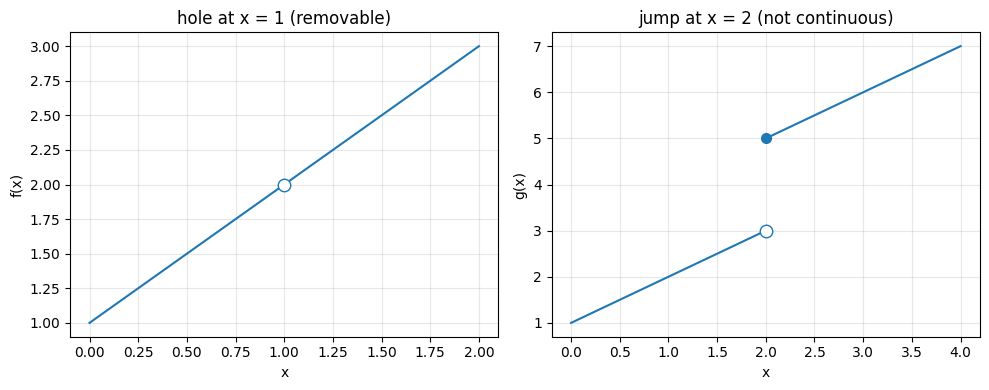

In [14]:
xs_left = np.linspace(0, 1.999, 200)
xs_right = np.linspace(2, 4, 200)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
xs = np.linspace(0, 2, 400)
xs = xs[np.abs(xs - 1) > 1e-6]
plt.plot(xs, f(xs), color="tab:blue")
plt.plot(1, 2, "o", markerfacecolor="white", markeredgecolor="tab:blue", markersize=9)
plt.title("hole at x = 1 (removable)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(xs_left, g(xs_left), color="tab:blue")
plt.plot(xs_right, g(xs_right), color="tab:blue")
plt.plot(2, 3, "o", markerfacecolor="white", markeredgecolor="tab:blue", markersize=9)
plt.plot(2, 5, "o", color="tab:blue", markersize=7)
plt.title("jump at x = 2 (not continuous)")
plt.xlabel("x")
plt.ylabel("g(x)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

From the left g(x) heads toward 3 and from the right it heads toward 5, so the limit at x = 2 does not exist even though g(2) = 5 is defined. The graph shows it, there's a gap you'd have to lift your pencil to cross. So g fails the continuity test at x = 2, while f is only missing a single point and the pencil barely has to hop.

### Example 3: the epsilon-delta idea, checked with numbers

The formal definition says the limit of f(x) as x approaches a is L if you can make f(x) as close to L as you want (within some tiny epsilon) by making x close enough to a (within some delta).

Take `h(x) = 2x + 1` with a = 3 and L = 7. For this line, if |x - 3| < delta then |h(x) - 7| = 2|x - 3| < 2 * delta, so picking delta = epsilon / 2 should always work. Let me test that on a bunch of x values for a few different epsilons.

In [15]:
def h_line(x):
    return 2 * x + 1

a, L = 3, 7

for eps in [1.0, 0.1, 0.01, 0.001]:
    delta = eps / 2
    # points inside the delta window around 3 (not including 3 itself)
    test_x = np.linspace(a - delta, a + delta, 10001)
    test_x = test_x[np.abs(test_x - a) > 0]
    worst_error = np.max(np.abs(h_line(test_x) - L))
    # tiny tolerance because computers store decimals with a little rounding error
    print(f"epsilon = {eps:6.3f}, delta = {delta:7.4f}, biggest |h(x) - 7| in the window = {worst_error:.6f}, inside epsilon? {worst_error <= eps + 1e-12}")

epsilon =  1.000, delta =  0.5000, biggest |h(x) - 7| in the window = 1.000000, inside epsilon? True
epsilon =  0.100, delta =  0.0500, biggest |h(x) - 7| in the window = 0.100000, inside epsilon? True
epsilon =  0.010, delta =  0.0050, biggest |h(x) - 7| in the window = 0.010000, inside epsilon? True
epsilon =  0.001, delta =  0.0005, biggest |h(x) - 7| in the window = 0.001000, inside epsilon? True


For every epsilon I tried, the worst case error inside the delta window stays within epsilon, so delta = epsilon / 2 does the job. That's the definition working in practice, as epsilon shrinks, delta shrinks along with it, and the function values stay trapped near 7.

A small note on that `1e-12` in the code. At the edge of the window the error is exactly equal to epsilon (that's what picking delta = epsilon / 2 gives for a line), and the computer's rounding can push it a hair over, like 0.0010000000000001. Without the tiny tolerance the last row printed False even though the math is fine, which was a good reminder that comparing decimals with a strict inequality can bite you.

## 3.2.2 Derivatives

The derivative is a limit too. It's the slope of the secant line between two points as the gap between them closes to zero:

`f'(a) = limit as h goes to 0 of (f(a + h) - f(a)) / h`

I want a real example here, so I'm using a learning curve. Say a student's expected score after studying for t hours looks like `S(t) = 100 * (1 - e^(-0.3 t))`. It rises fast at first and then levels off, which matches what I see with students (the first few hours help a lot, the tenth hour helps way less). The derivative S'(t) is the extra points you get from one more hour, right at time t.

In [16]:
def S(t):
    return 100 * (1 - np.exp(-0.3 * t))

t0 = 2.0

# the derivative worked out by hand: S'(t) = 100 * 0.3 * e^(-0.3 t) = 30 e^(-0.3 t)
def S_prime_exact(t):
    return 30 * np.exp(-0.3 * t)

print("exact derivative at t = 2:", S_prime_exact(t0))
print()
print("       h        forward difference     error")
for h in [1, 0.1, 0.01, 0.001, 0.0001]:
    forward = (S(t0 + h) - S(t0)) / h
    print(f"{h:9.4f}      {forward:12.6f}      {abs(forward - S_prime_exact(t0)):.2e}")

exact derivative at t = 2: 16.464349082820792

       h        forward difference     error
   1.0000         14.224198      2.24e+00
   0.1000         16.219835      2.45e-01
   0.0100         16.439677      2.47e-02
   0.0010         16.461880      2.47e-03
   0.0001         16.464102      2.47e-04


As h shrinks the difference quotient settles down to about 16.46, which is the exact derivative I computed by hand. So at 2 hours of studying, one more hour is worth roughly 16 more points. The error shrinks along with h, which is the limit definition in action.

In [17]:
# two ways to approximate: forward difference vs central difference
h = 0.1
forward = (S(t0 + h) - S(t0)) / h
central = (S(t0 + h) - S(t0 - h)) / (2 * h)

print("true value      :", S_prime_exact(t0))
print("forward (h=0.1) :", forward, " error:", abs(forward - S_prime_exact(t0)))
print("central (h=0.1) :", central, " error:", abs(central - S_prime_exact(t0)))

# let sympy do the symbolic derivative as an independent check
t = sp.symbols("t")
S_sym = 100 * (1 - sp.exp(-0.3 * t))
S_prime_sym = sp.diff(S_sym, t)
print("\nsympy derivative:", S_prime_sym)
print("sympy value at t = 2:", float(S_prime_sym.subs(t, 2)))

true value      : 16.464349082820792
forward (h=0.1) : 16.219835087129226  error: 0.24451399569156607
central (h=0.1) : 16.466818846319953  error: 0.0024697634991603934

sympy derivative: 30.0*exp(-0.3*t)
sympy value at t = 2: 16.464349082820792


The central difference is way more accurate than the forward difference for the same h, because looking at a point on each side cancels out the biggest chunk of the error. Sympy's symbolic answer matches my hand derivative, so I can trust it.

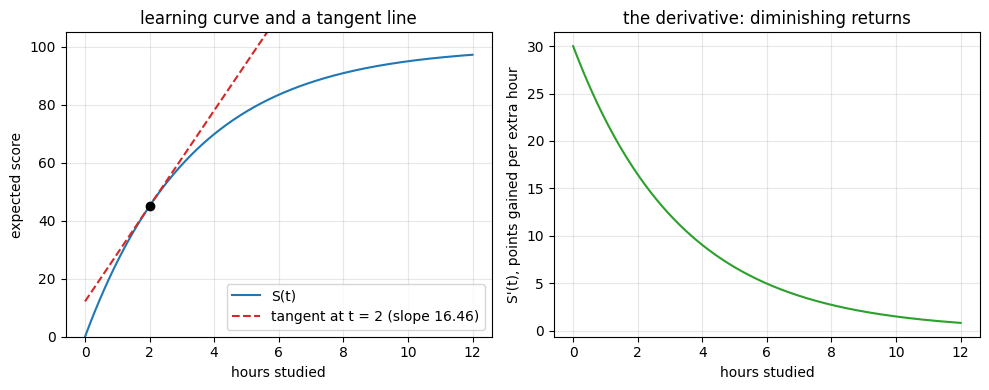

In [18]:
ts = np.linspace(0, 12, 400)
slope = S_prime_exact(t0)
tangent = S(t0) + slope * (ts - t0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(ts, S(ts), color="tab:blue", label="S(t)")
plt.plot(ts, tangent, color="tab:red", linestyle="--", label=f"tangent at t = 2 (slope {slope:.2f})")
plt.plot(t0, S(t0), "o", color="black")
plt.ylim(0, 105)
plt.xlabel("hours studied")
plt.ylabel("expected score")
plt.title("learning curve and a tangent line")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ts, S_prime_exact(ts), color="tab:green")
plt.xlabel("hours studied")
plt.ylabel("S'(t), points gained per extra hour")
plt.title("the derivative: diminishing returns")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The left plot shows the tangent line touching the curve at t = 2, and its slope is that 16.46 number. The right plot is the derivative itself. It starts at 30 points per hour and drops steadily toward 0, which is the diminishing returns idea. A derivative that's always positive but shrinking is the calculus way of saying "studying always helps, just less and less".

## 3.2.3 Taylor's Theorem

Taylor's theorem says a smooth function can be approximated near a point by a polynomial built from its derivatives at that point. Around 0 the degree n Taylor polynomial is

`P_n(x) = f(0) + f'(0) x + f''(0) x^2 / 2! + ... + f^(n)(0) x^n / n!`

and the theorem also tells you the error is controlled by the next term (the Lagrange remainder):

`|f(x) - P_n(x)| <= M * |x|^(n+1) / (n+1)!`

where M is a bound on the (n+1)th derivative.

I'll use `f(x) = sin(x)` around 0, since all its derivatives are easy (they cycle through sin, cos, -sin, -cos) and are all between -1 and 1, so M = 1 works for the remainder bound.

In [19]:
from math import factorial

def taylor_sin(x, n):
    # sum the odd terms of the sin series up to degree n
    total = np.zeros_like(x, dtype=float)
    for k in range(0, n + 1):
        if k % 2 == 1:
            total += ((-1) ** ((k - 1) // 2)) * x**k / factorial(k)
    return total

# check the coefficients against sympy's own series expansion
print("sympy series for sin(x):", sp.series(sp.sin(x), x, 0, 8))
print("my degree 7 polynomial at x = 0.5:", float(taylor_sin(np.array(0.5), 7)))
print("actual sin(0.5)                  :", np.sin(0.5))

sympy series for sin(x): x - x**3/6 + x**5/120 - x**7/5040 + O(x**8)
my degree 7 polynomial at x = 0.5: 0.479425533234127
actual sin(0.5)                  : 0.479425538604203


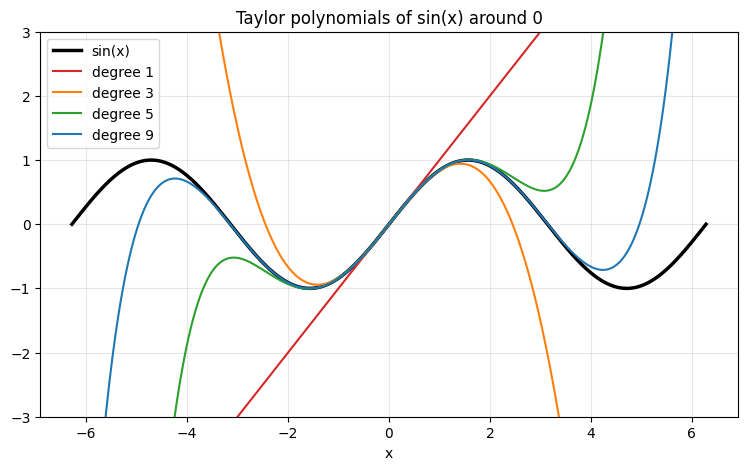

In [20]:
xs = np.linspace(-2 * np.pi, 2 * np.pi, 600)

plt.figure(figsize=(9, 5))
plt.plot(xs, np.sin(xs), color="black", linewidth=2.5, label="sin(x)")
for n, color in [(1, "tab:red"), (3, "tab:orange"), (5, "tab:green"), (9, "tab:blue")]:
    plt.plot(xs, taylor_sin(xs, n), color=color, label=f"degree {n}")
plt.ylim(-3, 3)
plt.xlabel("x")
plt.title("Taylor polynomials of sin(x) around 0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Each higher degree hugs the sine curve over a wider stretch before it flies off. Near 0 even the degree 1 line (just y = x) is decent, which is the small angle approximation you see in physics. Out near the edges you need much higher degrees. That's the main idea, Taylor polynomials are good close to the center and get worse the farther out you go.

In [21]:
# test the remainder bound at x = 1.5 for increasing degree
x_test = 1.5
true_value = np.sin(x_test)

print(" degree   Taylor value    actual error     remainder bound     bound holds?")
for n in [1, 3, 5, 7, 9]:
    approx = float(taylor_sin(np.array(x_test), n))
    error = abs(true_value - approx)
    bound = (abs(x_test) ** (n + 1)) / factorial(n + 1)    # M = 1 for sin
    print(f"{n:6d}   {approx:13.8f}   {error:13.3e}    {bound:13.3e}        {error <= bound}")

 degree   Taylor value    actual error     remainder bound     bound holds?
     1      1.50000000       5.025e-01        1.125e+00        True
     3      0.93750000       5.999e-02        2.109e-01        True
     5      1.00078125       3.286e-03        1.582e-02        True
     7      0.99739118       1.038e-04        6.356e-04        True
     9      0.99749712       2.136e-06        1.589e-05        True


Two things to notice. First, the actual error drops really fast as the degree goes up, from about 0.5 at degree 1 down to around 2e-6 at degree 9. Second, the Lagrange bound is always at least as big as the real error, so the theorem holds up in every row. The bound isn't exact (it's a worst case guarantee), but it's the right order of magnitude and it shrinks just as quickly, which is what makes Taylor's theorem useful, you can know how many terms you need before you start.

## Reflection and Submission Checklist

- I explained each idea in my own words before the code.
- I checked things numerically instead of just trusting the formulas (limits squeezing in from both sides and matching sympy, the epsilon-delta window test, difference quotients converging to the hand derivative, and the Taylor remainder bound holding at every degree).
- I used examples from my tutoring job (a learning curve for score vs hours studied, and a made up grading rule for the jump).
- I ran every cell top to bottom in Colab with no errors.
- I saved the notebook straight from Google Colab to GitHub so the Open in Colab badge works.